## Problem Statement

### Context

AllLife Bank is a mid-sized, fast-growing US-based financial institution that offers a range of retail banking services, including savings and checking accounts, fixed deposits, and personal loans. The bank’s business model is centered on building long-term customer relationships, expanding its retail footprint, and growing its loan portfolio to drive sustainable profitability through interest income.

It currently relies on a large base of liability customers (depositors) but faces a significant under-representation of asset customers (borrowers). To drive profitability through interest income, the bank must aggressively expand its loan portfolio by converting existing depositors into personal loan customers.

Last year’s pilot campaign achieved a 9% conversion rate, validating the potential of this strategy. However, to optimize marketing spend and improve efficiency, the retail marketing department requires a more data-driven approach. Enhancing the success ratio of these campaigns is critical for sustainable growth and maximizing customer lifetime value.

### Objective

The objective is to develop a predictive classification model that identifies patterns and key factors driving personal loan adoption among existing liability customers. By uncovering the demographic and behavioral drivers of loan conversion, the goal is to enable targeted segmentation and more precise marketing interventions that improve campaign conversion rates, optimize marketing spend, and enhance overall profitability through higher-quality loan portfolio growth.

### Data Dictionary

* `ID`: Customer ID
* `Age`: Customer’s age in completed years
* `Experience`: #years of professional experience
* `Income`: Annual income of the customer (in thousand dollars)
* `ZIP Code`: Home Address ZIP code.
* `Family`: the Family size of the customer
* `CCAvg`: Average spending on credit cards per month (in thousand dollars)
* `Education`: Education Level. 1: Undergrad; 2: Graduate;3: Advanced/Professional
* `Mortgage`: Value of house mortgage if any. (in thousand dollars)
* `Personal_Loan`: Did this customer accept the personal loan offered in the last campaign? (0: No, 1: Yes)
* `Securities_Account`: Does the customer have securities account with the bank? (0: No, 1: Yes)
* `CD_Account`: Does the customer have a certificate of deposit (CD) account with the bank? (0: No, 1: Yes)
* `Online`: Do customers use internet banking facilities? (0: No, 1: Yes)
* `CreditCard`: Does the customer use a credit card issued by any other Bank (excluding All life Bank)? (0: No, 1: Yes)

## Importing necessary libraries

In [ ]:
# Installing the libraries with the specified version.
!pip install numpy==2.0.2 pandas==2.2.2 matplotlib==3.10.0 seaborn==0.13.2 scikit-learn==1.6.1 sklearn-pandas==2.2.0 -q --user

**Note**:

1. After running the above cell, kindly restart the notebook kernel (for Jupyter Notebook) or runtime (for Google Colab), write the relevant code for the project from the next cell, and run all cells sequentially from the next cell.

2. On executing the above line of code, you might see a warning regarding package dependencies. This error message can be ignored as the above code ensures that all necessary libraries and their dependencies are maintained to successfully execute the code in this notebook.

In [ ]:
import pandas as pd
import numpy as np

# to visualize data
import matplotlib.pyplot as plt
import seaborn as sns

## Loading the dataset

In [ ]:
#importing google coloab to access google drive files
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# loading data into a pandas dataframe
customer_loan_acceptance = pd.read_csv('/content/drive/MyDrive/Austin Coursework/Loan_Modelling.csv')

In [ ]:
#creating a copy of the data to preserve original data
loan_data = customer_loan_acceptance.copy()

## Data Overview

* Observations
* Sanity checks

Examine first five rows and last rows

In [ ]:
#first five rows
loan_data.head(5)

,ID,Age,Experience,Income,ZIPCode,Family,CCAvg,Education,Mortgage,Personal_Loan,Securities_Account,CD_Account,Online,CreditCard
0,1,25,1,49,91107,4,1.6,1,0,0,1,0,0,0
1,2,45,19,34,90089,3,1.5,1,0,0,1,0,0,0
2,3,39,15,11,94720,1,1.0,1,0,0,0,0,0,0
3,4,35,9,100,94112,1,2.7,2,0,0,0,0,0,0
4,5,35,8,45,91330,4,1.0,2,0,0,0,0,0,1


In [ ]:
#first five rows
loan_data.tail(5)

,ID,Age,Experience,Income,ZIPCode,Family,CCAvg,Education,Mortgage,Personal_Loan,Securities_Account,CD_Account,Online,CreditCard
4995,4996,29,3,40,92697,1,1.9,3,0,0,0,0,1,0
4996,4997,30,4,15,92037,4,0.4,1,85,0,0,0,1,0
4997,4998,63,39,24,93023,2,0.3,3,0,0,0,0,0,0
4998,4999,65,40,49,90034,3,0.5,2,0,0,0,0,1,0
4999,5000,28,4,83,92612,3,0.8,1,0,0,0,0,1,1


The head() and tail() outputs confirm that the dataset has been loaded correctly, with all columns matching the data dictionary

Check shape and attributes type

In [ ]:
loan_data.shape

(5000, 14)

Data has 5000 rows and 14 columns

In [ ]:
loan_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ID                  5000 non-null   int64  
 1   Age                 5000 non-null   int64  
 2   Experience          5000 non-null   int64  
 3   Income              5000 non-null   int64  
 4   ZIPCode             5000 non-null   int64  
 5   Family              5000 non-null   int64  
 6   CCAvg               5000 non-null   float64
 7   Education           5000 non-null   int64  
 8   Mortgage            5000 non-null   int64  
 9   Personal_Loan       5000 non-null   int64  
 10  Securities_Account  5000 non-null   int64  
 11  CD_Account          5000 non-null   int64  
 12  Online              5000 non-null   int64  
 13  CreditCard          5000 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 547.0 KB


No null values

*   No null values
*   All the variables are classifed in the data as numerical.
Personal_Loan, Securities_Account, CD_Account, Online, CreditCard variables although interpreted here as numerical, are categorical variables that are encoded by default.
*   Education variable is label encoded
*   ID variable do not provide meaningful value for predictions




Checking the statistical summary

In [ ]:
loan_data.describe()

,ID,Age,Experience,Income,ZIPCode,Family,CCAvg,Education,Mortgage,Personal_Loan,Securities_Account,CD_Account,Online,CreditCard
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.00000,5000.000000,5000.000000
mean,2500.500000,45.338400,20.104600,73.774200,93169.257000,2.396400,1.937938,1.881000,56.498800,0.096000,0.104400,0.06040,0.596800,0.294000
std,1443.520003,11.463166,11.467954,46.033729,1759.455086,1.147663,1.747659,0.839869,101.713802,0.294621,0.305809,0.23825,0.490589,0.455637
min,1.000000,23.000000,-3.000000,8.000000,90005.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
25%,1250.750000,35.000000,10.000000,39.000000,91911.000000,1.000000,0.700000,1.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
50%,2500.500000,45.000000,20.000000,64.000000,93437.000000,2.000000,1.500000,2.000000,0.000000,0.000000,0.000000,0.00000,1.000000,0.000000
75%,3750.250000,55.000000,30.000000,98.000000,94608.000000,3.000000,2.500000,3.000000,101.000000,0.000000,0.000000,0.00000,1.000000,1.000000
max,5000.000000,67.000000,43.000000,224.000000,96651.000000,4.000000,10.000000,3.000000,635.000000,1.000000,1.000000,1.00000,1.000000,1.000000


*   Age of the applicants are in the range of 23 and 67 with average being 45 years
*   Only 9.6% of the applicants accepted personal loan.(0.096 mean)
*   Experience has negative values, This will require appropriate treatment during preprocessing.
*   Income is in the range of 8k to 224 k with average at 73k. (data contains low income and high income applicants)
*   50% of the applicants do not have a Mortgage as the median value is 0 (50%)
*   Avg Credit card spending is 1.9K $ and 50% of the applicats are below this range.



   






Check missing values

In [ ]:
# checking for null values
loan_data.isnull().sum()

,0
ID,0
Age,0
Experience,0
Income,0
ZIPCode,0
Family,0
CCAvg,0
Education,0
Mortgage,0
Personal_Loan,0


No missing values in the dataset

Duplicate value check

In [ ]:
loan_data.duplicated().sum()

np.int64(0)

no duplicate values in the data.

## Exploratory Data Analysis.

EDA is a critical step in any data project used to investigate and understand the data before model construction.

The following questions serve as a starting point to help you approach the analysis and generate initial insights:

**Questions**:
1. What is the distribution of mortgage attribute? Are there any noticeable patterns or outliers in the distribution?
2. How many customers have credit cards?
3. What are the attributes that have a strong correlation with the target attribute (personal loan)?
4. How does a customer's interest in purchasing a loan vary with their education?
5. How does a customer's interest in purchasing a loan vary with their age?

**[IMPORTANT]** Beyond the Basics: Please note that these are guiding questions only. To receive full points for this rubric section, you are expected to perform a thorough analysis that goes beyond these specific questions to uncover deeper trends and relationships within the data.

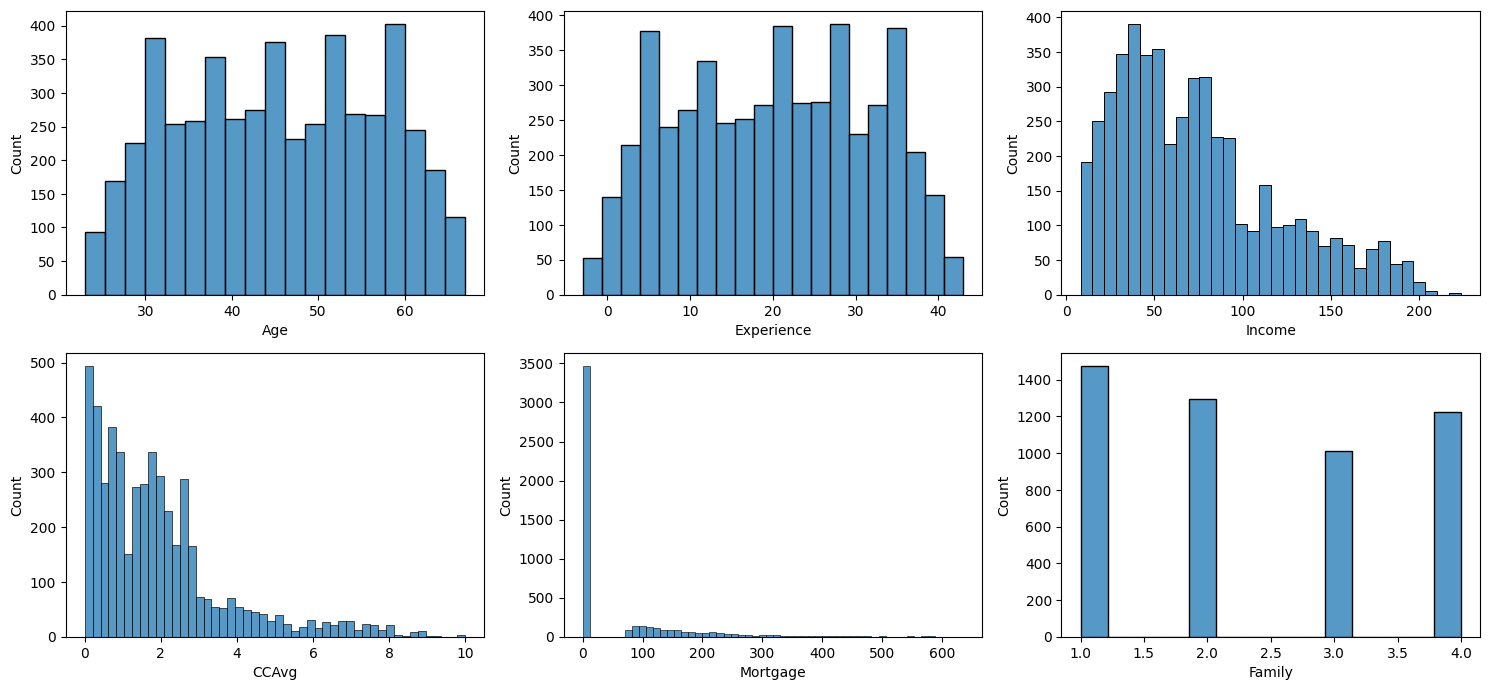

In [ ]:
# defining the figure size
plt.figure(figsize=(15, 10))

# defining the list of numerical features to plot
num_features = ['Age', 'Experience', 'Income','CCAvg','Mortgage','Family']

# plotting the histogram for each numerical feature
for i, feature in enumerate(num_features):
    plt.subplot(3, 3, i+1)    # assign a subplot in the main plot
    sns.histplot(data=loan_data, x=feature)    # plot the histogram

plt.tight_layout();   # to add spacing between plots

Age is evenly distributed, with most customers between 30 and 60 years and no significant outliers.
Experience is spread across a wide range but contains negative values which are not valid.
Income is right-skewed, with most customers earning below 100k and a few high-income outliers.
Credit card spending is right-skewed, with most customers spending less than 4k
Mortgage values are highly skewed, with more than half of the customers having no mortgage.
Family size is concentrated around smaller households, with most customers having 1 to 3 family members.

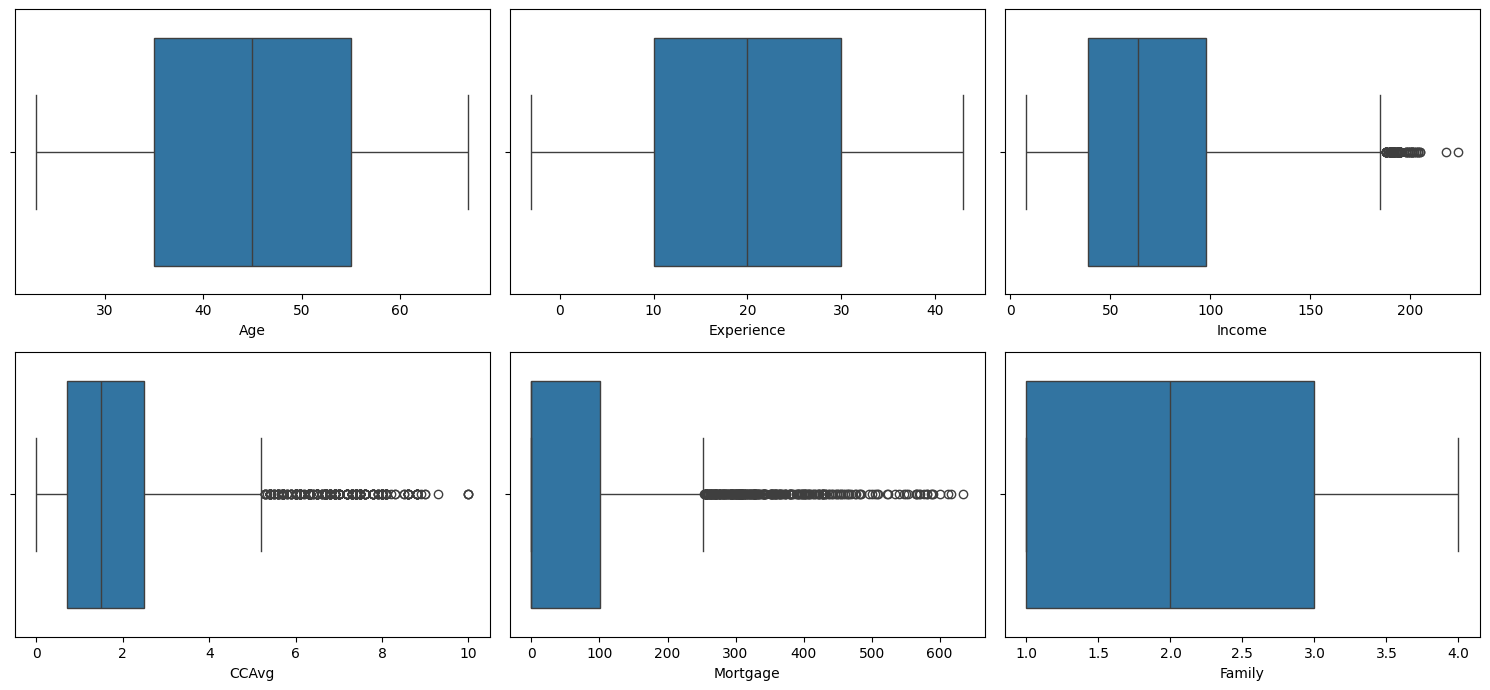

In [ ]:
# defining the figure size
plt.figure(figsize=(15, 10))

# plotting the boxplot for each numerical feature
for i, feature in enumerate(num_features):
    plt.subplot(3, 3, i+1)    # assign a subplot in the main plot
    sns.boxplot(data=loan_data, x=feature)    # plot the histogram

plt.tight_layout();    # to add spacing between plots

Outliers are observed in Income, CCAvg, and Mortgage variables, indicating high-income customers, The Experience variable contains negative values needs to be cleaned

Personal_Loan
0    90.4
1     9.6
Name: proportion, dtype: float64 

Securities_Account
0    89.56
1    10.44
Name: proportion, dtype: float64 

CD_Account
0    93.96
1     6.04
Name: proportion, dtype: float64 

Online
1    59.68
0    40.32
Name: proportion, dtype: float64 

CreditCard
0    70.6
1    29.4
Name: proportion, dtype: float64 



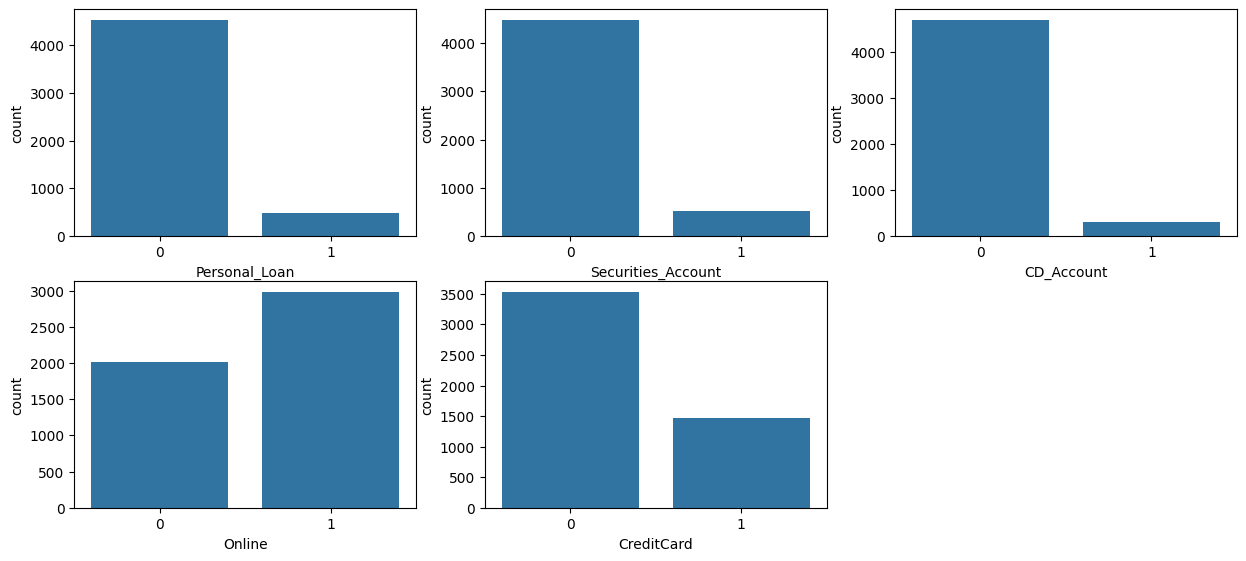

In [ ]:
# checking the distribution of the categories in binary categories
plt.figure(figsize=(15, 10))
binary_categories = ['Personal_Loan', 'Securities_Account', 'CD_Account','Online','CreditCard']
for i, feature in enumerate(binary_categories):
  plt.subplot(3, 3, i+1)
  print(100*loan_data[feature].value_counts(normalize=True), '\n')
  sns.countplot(data=loan_data, x=feature);

Around 90% of customers did not accept personal loans, indicating strong class imbalance. Similarly, most customers do not have securities or CD accounts. More than half of the customers use online banking, while about 70% of customers hold credit cards.

Bivariate Analysis

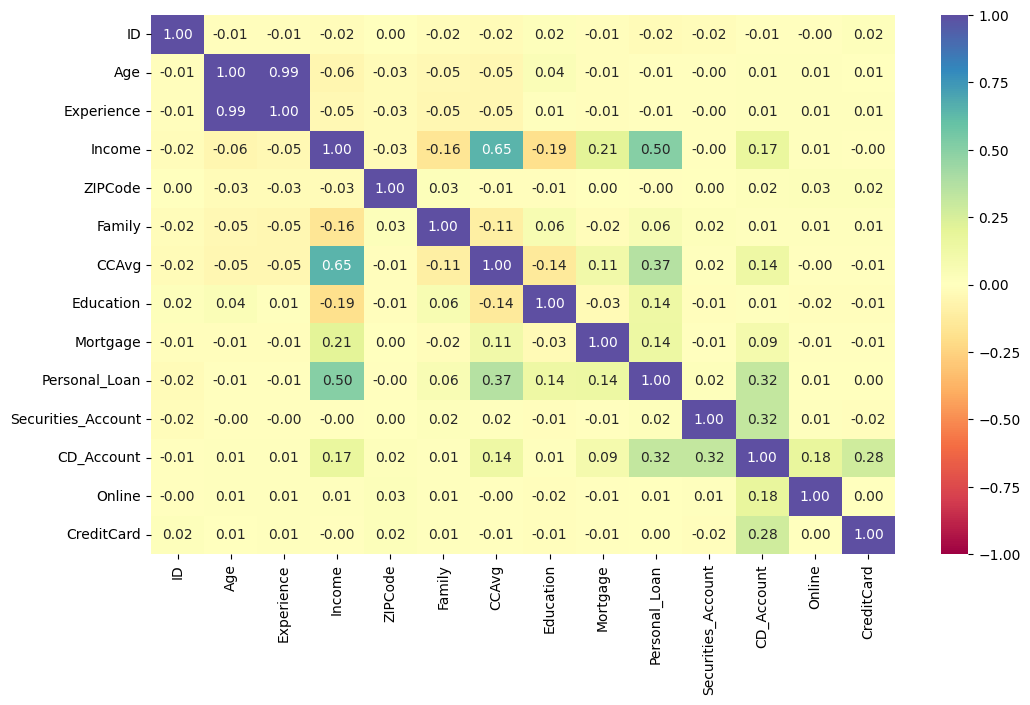

In [ ]:
# defining the size of the plot
plt.figure(figsize=(12, 7))

# plotting the heatmap for correlation
sns.heatmap(
    loan_data.corr(),annot=True, vmin=-1, vmax=1, fmt=".2f", cmap="Spectral"
);

Age and Experience are highly correlated. As the age of the applicants increases, the experience of the applicant increase.
Credit card spending increases as salary increases

As credit card spending increases Personal loan acceptance increases.
As income increases, personal loan acceptance increases

<Figure size 1200x800 with 0 Axes>

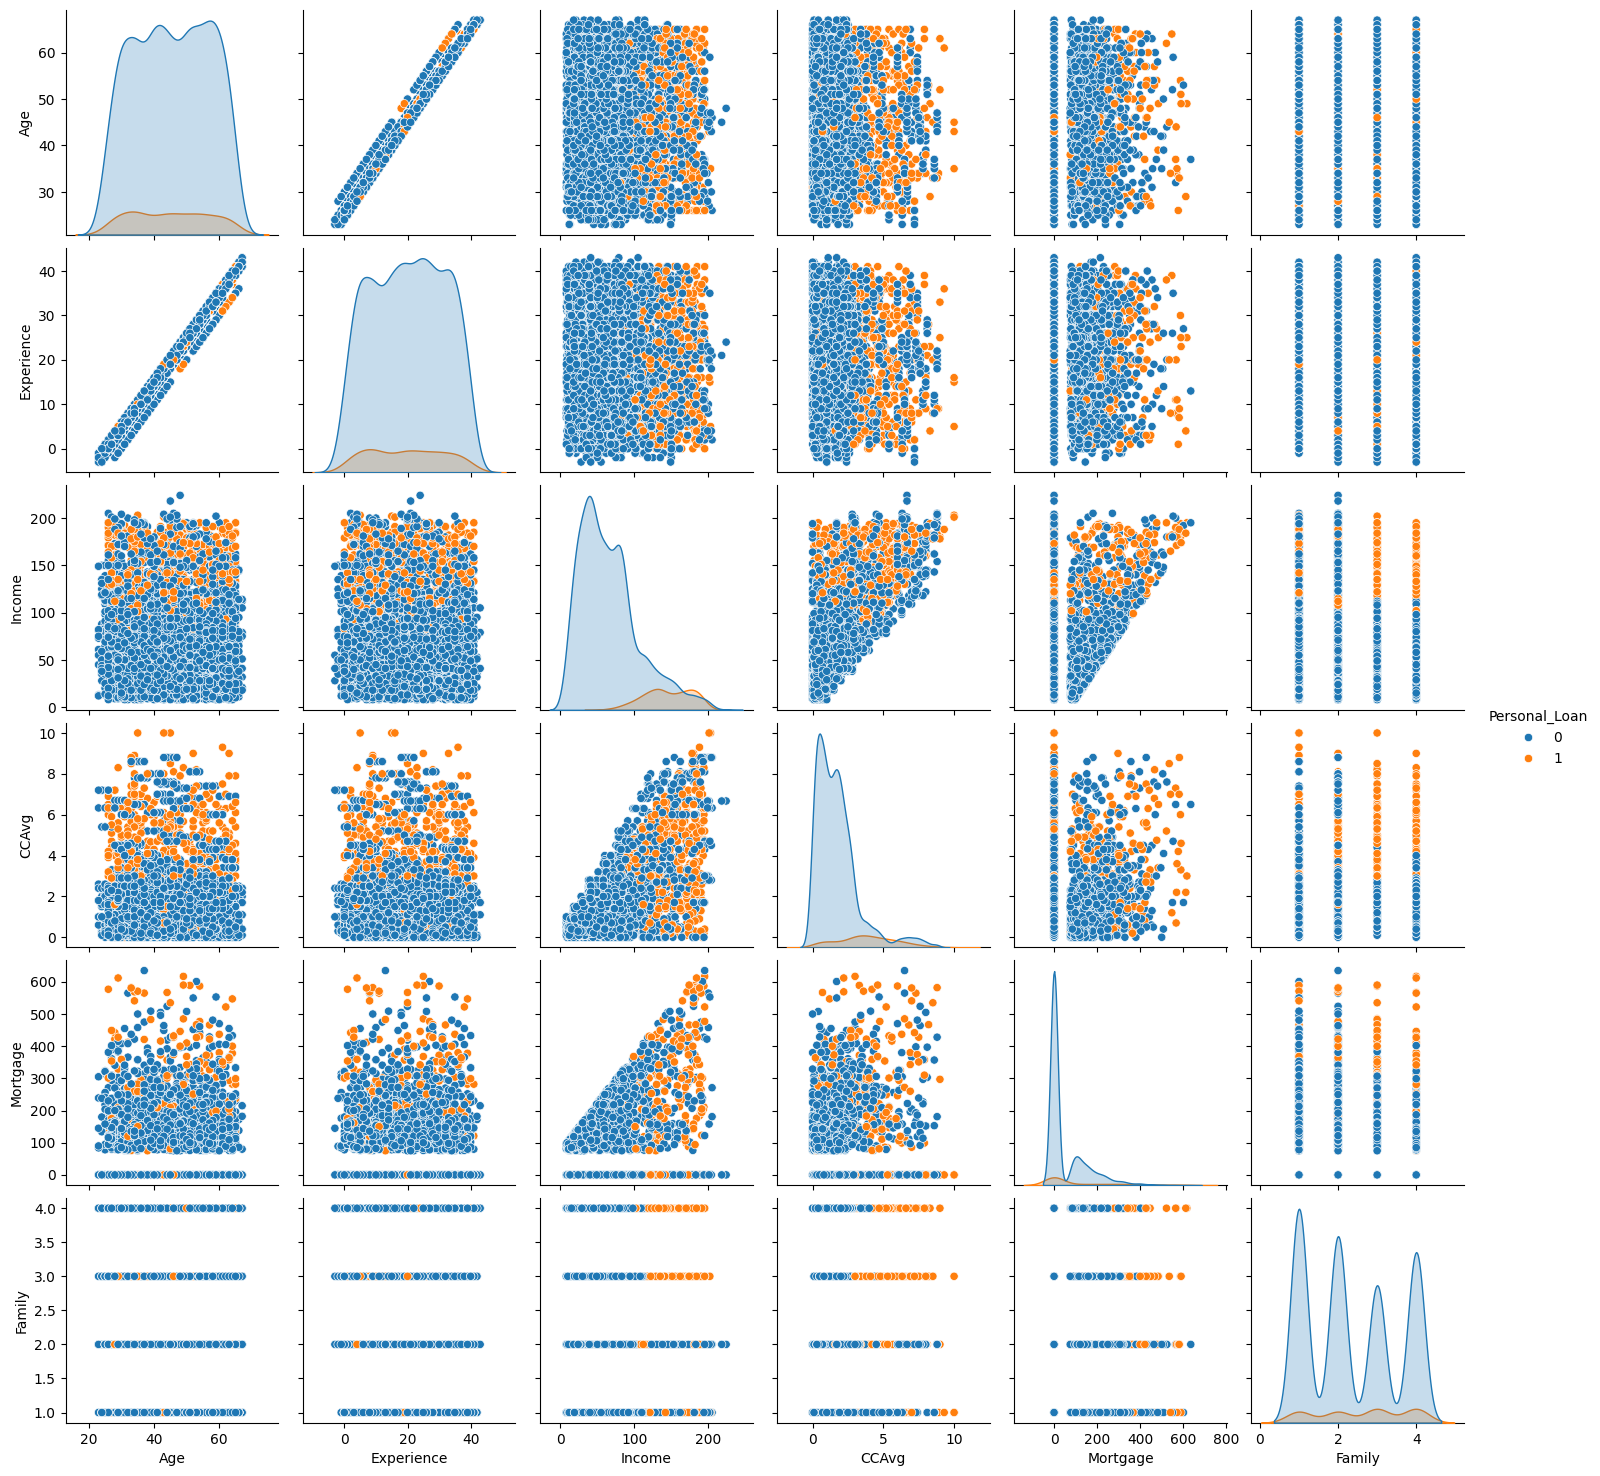

In [ ]:
# Scatter plot matrix
plt.figure(figsize=(12, 8))
sns.pairplot(loan_data, vars=num_features, hue='Personal_Loan', diag_kind='kde');

customers who accepted loans have higher income and higher credit card spending.

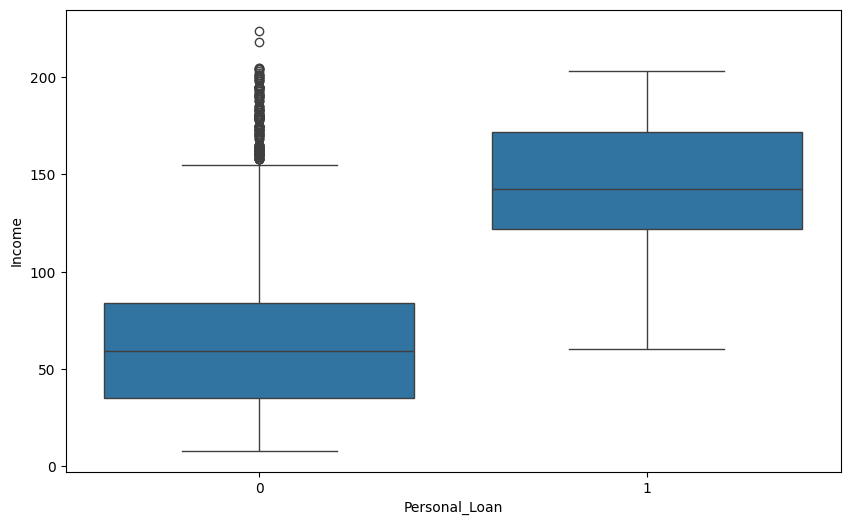

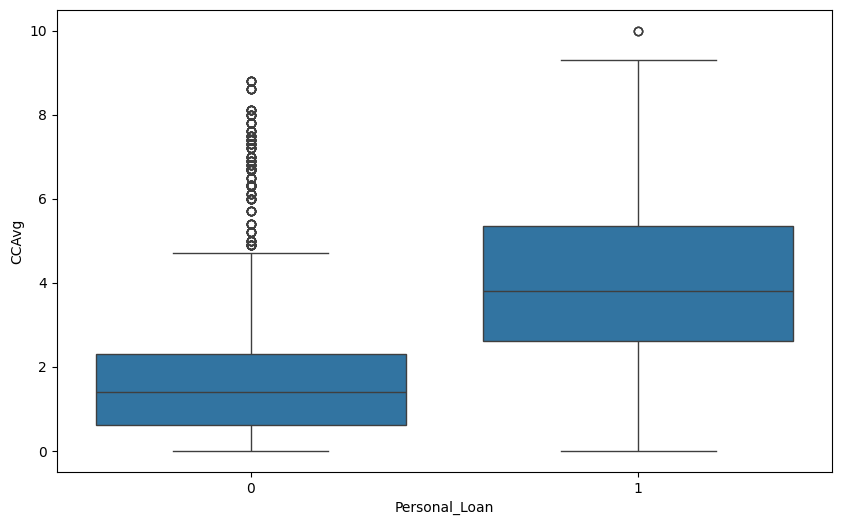

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='Personal_Loan', y='Income', data=loan_data)
plt.show()

plt.figure(figsize=(10, 6))
sns.boxplot(x='Personal_Loan', y='CCAvg', data=loan_data)
plt.show()

Customers who accepted personal loans tend to have higher income and higher credit card spending (same trend seen in previous graphs as well)

In [ ]:
print(pd.crosstab(loan_data['Education'], loan_data['Personal_Loan'], normalize='index'))
print(pd.crosstab(loan_data['CD_Account'], loan_data['Personal_Loan'], normalize='index'))
print(pd.crosstab(loan_data['Securities_Account'], loan_data['Personal_Loan'], normalize='index'))

Personal_Loan         0         1
Education                        
1              0.955630  0.044370
2              0.870278  0.129722
3              0.863424  0.136576
Personal_Loan         0         1
CD_Account                       
0              0.927629  0.072371
1              0.536424  0.463576
Personal_Loan              0         1
Securities_Account                    
0                   0.906208  0.093792
1                   0.885057  0.114943


Customers with higher education levels, CD accounts, securities accounts show a higher chance of accepting personal loans.

## Data Preprocessing

* Missing value treatment
* Feature engineering (if needed)
* Outlier detection and treatment (if needed)
* Preparing data for modeling
* Any other preprocessing steps (if needed)

No missing Values
No issues with data types
Income, CCAvg, Mortgage has outliers however this is expected (High income are usually low in numbers)
Experience has negative values needs to be fixed.
ID and ZIP has no value(ZIP has importance when buying homes not for personal loan acceptance)
Personal_Loan, Securities_Account,CD_Account, Online, CreditCard doesn't require encoding (the values are encoded)


In [ ]:
#Dropping ID and ZIP
loan_data.columns
loan_data = loan_data.drop(['ID', 'ZIPCode'], axis=1)
# Finding negative values
print((loan_data['Experience'] < 0).sum())

52


In [ ]:
print((loan_data['Experience'] < 0).sum())

52


52 rows are 1% of the data, can be removed.

In [ ]:
loan_data = loan_data[loan_data['Experience'] >= 0]
print(loan_data.shape)

(4948, 12)


Original shape: (5000, 14)
Current shape: (4948, 12)

In [ ]:
from sklearn.model_selection import train_test_split
X = loan_data.drop('Personal_Loan', axis=1)
y = loan_data['Personal_Loan']

# splitting the data in an 80:20 ratio for train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, stratify=y, random_state=42)

In [ ]:
print("Shape of training set:", X_train.shape)
print("Shape of test set:", X_test.shape, '\n')
print("Percentage of classes in training set:")
print(100*y_train.value_counts(normalize=True), '\n')
print("Percentage of classes in test set:")
print(100*y_test.value_counts(normalize=True))

Shape of training set: (3958, 11)
Shape of test set: (990, 11) 

Percentage of classes in training set:
Personal_Loan
0    90.29813
1     9.70187
Name: proportion, dtype: float64 

Percentage of classes in test set:
Personal_Loan
0    90.30303
1     9.69697
Name: proportion, dtype: float64


Test and train has similar classes

## Model Building

##Decision Tree (sklearn default)

In [ ]:
# creating an instance of the decision tree model
from sklearn.tree import DecisionTreeClassifier
dtree1 = DecisionTreeClassifier(random_state=42)    # random_state sets a seed value and enables reproducibility

# fitting the model to the training data
dtree1.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

### Model Evaluation Criterion

In [ ]:
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    recall_score,
    precision_score,
    f1_score,
)

# defining a function to compute different metrics to check performance of a classification model built using sklearn
def model_performance_classification(model, predictors, target):
    """
    Function to compute different metrics to check classification model performance

    model: classifier
    predictors: independent variables
    target: dependent variable
    """

    # predicting using the independent variables
    pred = model.predict(predictors)

    acc = accuracy_score(target, pred)  # to compute Accuracy
    recall = recall_score(target, pred)  # to compute Recall
    precision = precision_score(target, pred)  # to compute Precision
    f1 = f1_score(target, pred)  # to compute F1-score

    # creating a dataframe of metrics
    df_perf = pd.DataFrame(
        {"Accuracy": acc, "Recall": recall, "Precision": precision, "F1": f1,},
        index=[0],
    )

    return df_perf

In [ ]:
def plot_confusion_matrix(model, predictors, target):
    """
    To plot the confusion_matrix with percentages

    model: classifier
    predictors: independent variables
    target: dependent variable
    """
    # Predict the target values using the provided model and predictors
    y_pred = model.predict(predictors)

    # Compute the confusion matrix comparing the true target values with the predicted values
    cm = confusion_matrix(target, y_pred)

    # Create labels for each cell in the confusion matrix with both count and percentage
    labels = np.asarray(
        [
            ["{0:0.0f}".format(item) + "\n{0:.2%}".format(item / cm.flatten().sum())]
            for item in cm.flatten()
        ]
    ).reshape(2, 2)    # reshaping to a matrix

    # Set the figure size for the plot
    plt.figure(figsize=(6, 4))

    # Plot the confusion matrix as a heatmap with the labels
    sns.heatmap(cm, annot=labels, fmt="")

    # Add a label to the y-axis
    plt.ylabel("True label")

    # Add a label to the x-axis
    plt.xlabel("Predicted label")

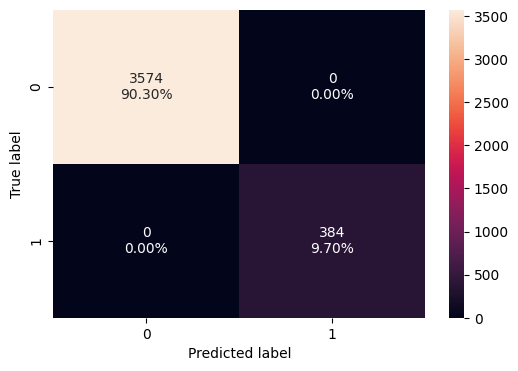

In [ ]:
plot_confusion_matrix(dtree1, X_train, y_train)

In [ ]:
dtree1_train_perf = model_performance_classification(
    dtree1, X_train, y_train
)
dtree1_train_perf

,Accuracy,Recall,Precision,F1
0,1.0,1.0,1.0,1.0


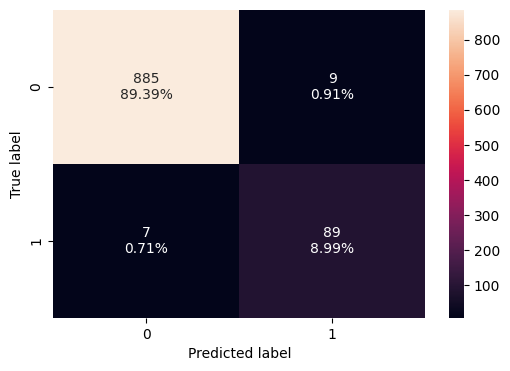

In [ ]:
plot_confusion_matrix(dtree1, X_test, y_test)

In [ ]:
dtree1_test_perf = model_performance_classification(
    dtree1, X_test, y_test
)
dtree1_test_perf

,Accuracy,Recall,Precision,F1
0,0.983838,0.927083,0.908163,0.917526


Observations:
F1 score and Recall are the most important metric in this problem, as it ensures that potential loan customers are correctly identified in the datasets. This model is really good because
Precision = 90%, Recall = 92% , F1 ≈ 91% on test results.
This Model sill shows signs of overfitting  because Training results are 100% perfect and testing results are sightly lower than Training results.
Visualizing the Decision Tree tells us how complex the model is, if the model is complex, we will try to apply  Pre-pruning and Post-pruning
and compare model performance

#### Visualizing the Decision Tree

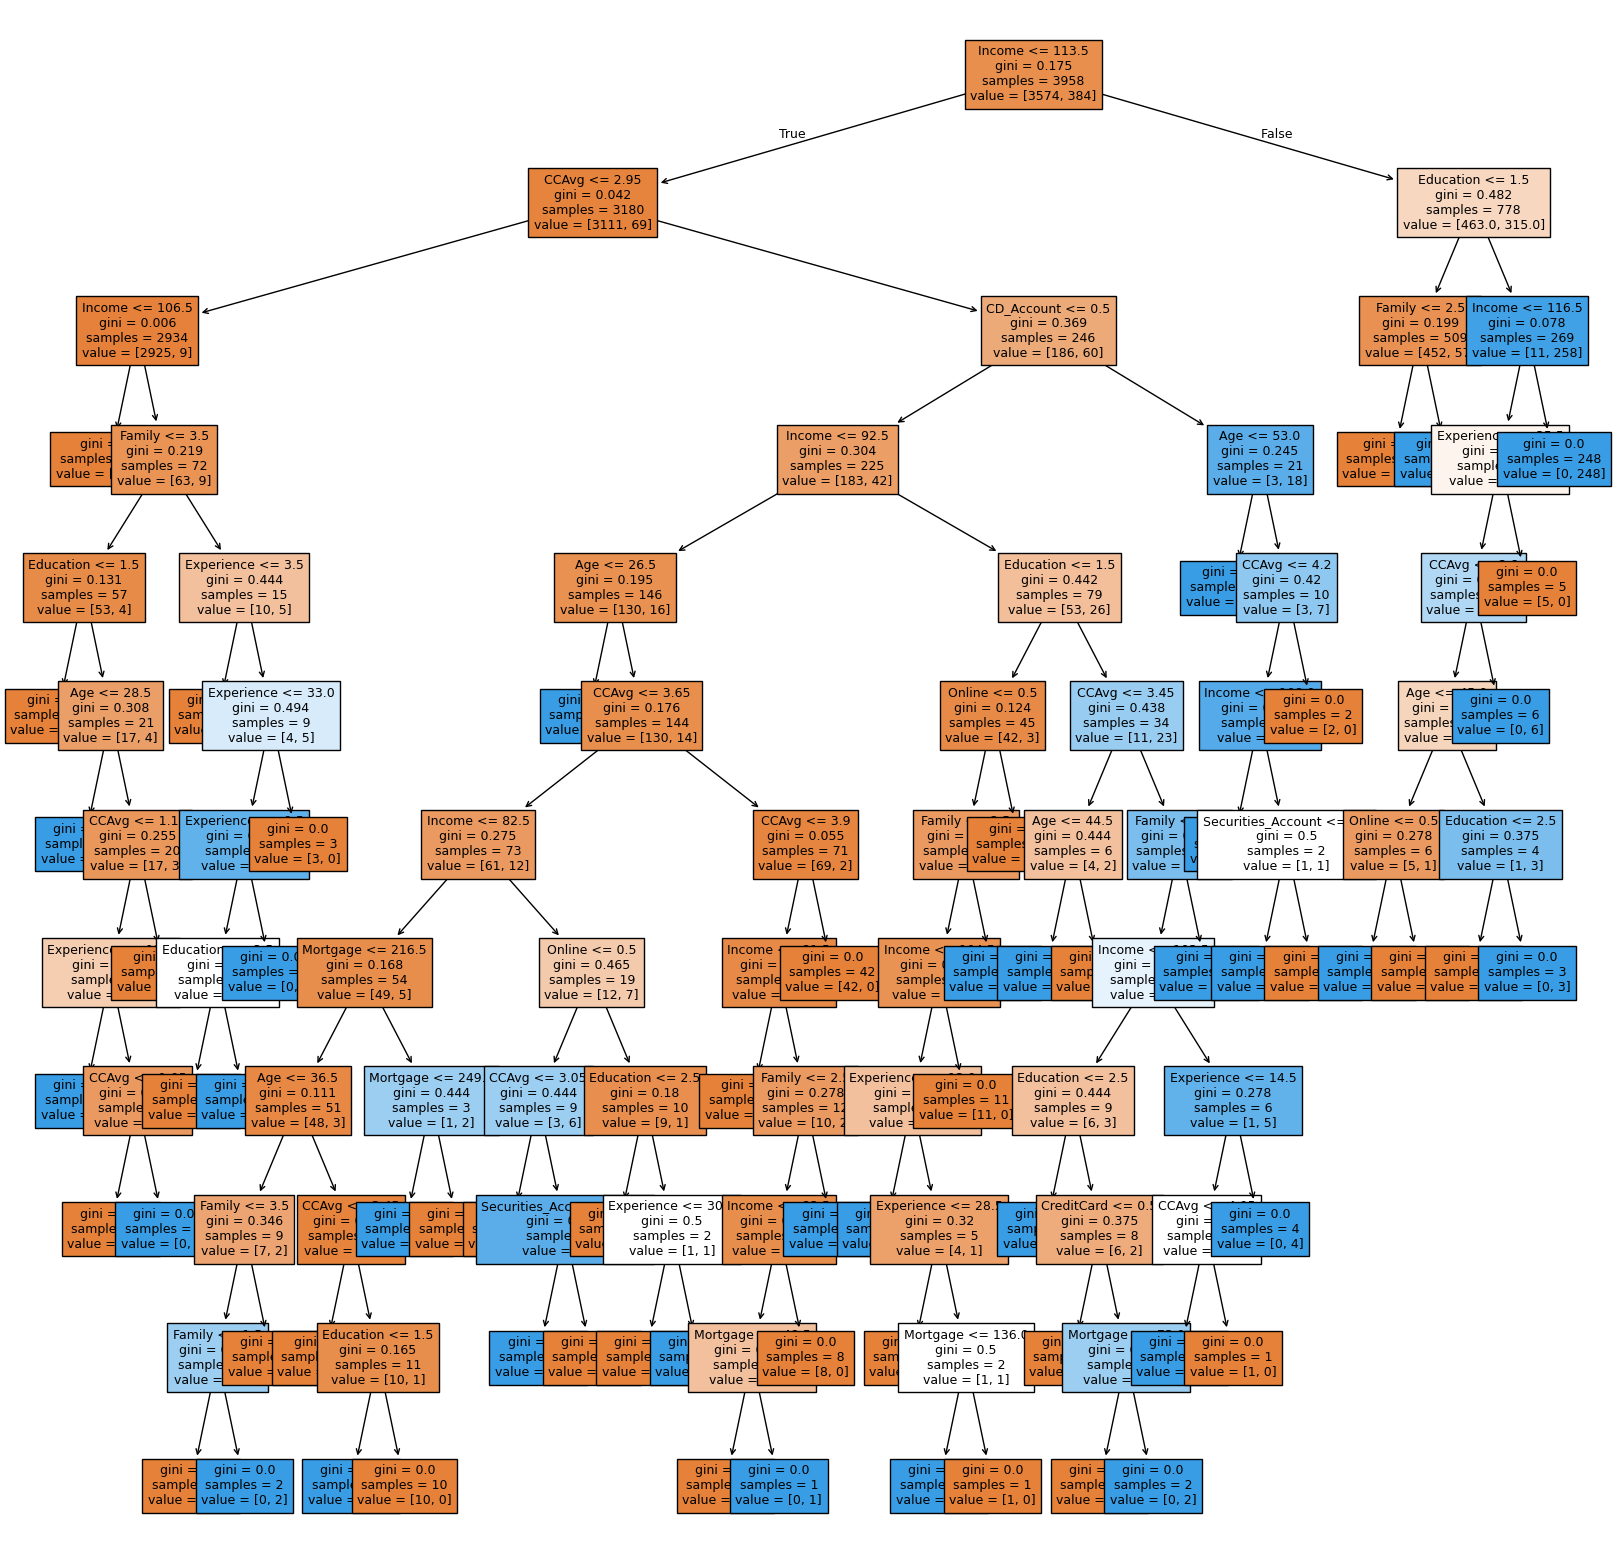

In [ ]:
from sklearn import tree
# list of feature names in X_train
feature_names = list(X_train.columns)

# set the figure size for the plot
plt.figure(figsize=(20, 20))

# plotting the decision tree
out = tree.plot_tree(
    dtree1,                         # decision tree classifier model
    feature_names=feature_names,    # list of feature names (columns) in the dataset
    filled=True,                    # fill the nodes with colors based on class
    fontsize=9,                     # font size for the node text
    node_ids=False,                 # do not show the ID of each node
    class_names=None,               # whether or not to display class names
)

# add arrows to the decision tree splits if they are missing
for o in out:
    arrow = o.arrow_patch
    if arrow is not None:
        arrow.set_edgecolor("black")    # set arrow color to black
        arrow.set_linewidth(1)          # set arrow linewidth to 1

# displaying the plot
plt.show()

The decision tree is complex, so we will apply pre-tuning and post-tuning strategies. we don't need to run the rules report for this complex tree showing the rules of a decision tree.
We will run the report on the decision tree that is not complex

Decision Tree (Pre-pruning)

The idea here is to limit the tree depth while having overall good performance, we do that by using the parameters max_depth_values, max_leaf_nodes_values, min_samples_split_values.
Instead of guessing one value at a time, checking the performance, updating the parameter values again, we set a range of values for the parameters, iterate over the values, and choose a model with good test performance and limited overfitting. We will focus on, high test recall, high test F1, small
gap between train and test

My goal here is  
1) find best Test F1 score and note test recall score & score difference for best Test F1 score
2) find best Test Recall score and note test F1 score & score difference
3) find best score and note test F1 score and test Recall
Through this I want to understand the best model.
Ideal model is to have the F1 score, best recall and low score difference, However it is not realistic.
By finding above 3 my goal is to find trade off and make better decisions.


In [ ]:
# define the parameters of the tree to iterate over
max_depth_values = np.arange(2, 11, 2)
max_leaf_nodes_values = np.arange(10, 51, 10)
min_samples_split_values = np.arange(10, 51, 10)

# initialize variables to store the best model and its performance
best_estimator = None
best_score_diff = float('inf')
best_test_f1_score = float('-inf')
best_test_recall_score = float('-inf')

# iterate over all combinations of the specified parameter values
for max_depth in max_depth_values:
    for max_leaf_nodes in max_leaf_nodes_values:
        for min_samples_split in min_samples_split_values:

            # initialize the tree with the current set of parameters
            estimator = DecisionTreeClassifier(
                max_depth=max_depth,
                max_leaf_nodes=max_leaf_nodes,
                min_samples_split=min_samples_split,
                random_state=42
            )

            # fit the model to the training data
            estimator.fit(X_train, y_train)

            # make predictions on the training and test sets
            y_train_pred = estimator.predict(X_train)
            y_test_pred = estimator.predict(X_test)

            # calculate F1 scores for training and test sets
            train_f1_score = f1_score(y_train, y_train_pred)
            test_f1_score = f1_score(y_test, y_test_pred)
            train_recall = recall_score(y_train, y_train_pred)
            test_recall = recall_score(y_test, y_test_pred)
            score_diff = abs(train_f1_score - test_f1_score)

            # best test f1
            if test_f1_score > best_test_f1_score:
                best_test_f1_score = test_f1_score
                score_diff_best_test_f1_score = score_diff
                test_recall_best_test_f1_score = test_recall
                estimator_best_test_f1_score = estimator

            # best test recall
            if test_recall > best_test_recall_score:
                best_test_recall_score = test_recall
                test_f1_score_best_test_recall_score = test_f1_score
                score_diff_best_test_recall_score = score_diff
                estimator_best_test_recall_score = estimator

            # smallest gap
            if score_diff < best_score_diff:
                best_score_diff = score_diff
                best_estimator_gap = estimator
                best_score_diff_f1_score = test_f1_score
                best_score_diff_recall_score = test_recall


print("Best Test F1 Model")
print("Test F1:", best_test_f1_score)
print("Train-Test F1 Gap:", score_diff_best_test_f1_score)
print("Test Recall:", test_recall_best_test_f1_score)
print("Estimator:", estimator_best_test_f1_score)

print("\nBest Recall Model")
print("Test Recall:", best_test_recall_score)
print("Test F1:", test_f1_score_best_test_recall_score)
print("Train-Test F1 Gap:", score_diff_best_test_recall_score)
print("Estimator:", estimator_best_test_recall_score)

print("\nSmallest Gap Model")
print("Train-Test F1 Gap:", best_score_diff)
print("Test F1:", best_score_diff_f1_score)
print("Test Recall:", best_score_diff_recall_score)
print("Estimator:", best_estimator_gap)





Best Test F1 Model
Test F1: 0.9197860962566845
Train-Test F1 Gap: 0.013189775056988373
Test Recall: 0.8958333333333334
Estimator: DecisionTreeClassifier(max_depth=np.int64(6), max_leaf_nodes=np.int64(10),
                       min_samples_split=np.int64(10), random_state=42)

Best Recall Model
Test Recall: 0.9270833333333334
Test F1: 0.9081632653061225
Train-Test F1 Gap: 0.05509132786973059
Estimator: DecisionTreeClassifier(max_depth=np.int64(8), max_leaf_nodes=np.int64(30),
                       min_samples_split=np.int64(10), random_state=42)

Smallest Gap Model
Train-Test F1 Gap: 0.013189775056988373
Test F1: 0.9197860962566845
Test Recall: 0.8958333333333334
Estimator: DecisionTreeClassifier(max_depth=np.int64(6), max_leaf_nodes=np.int64(10),
                       min_samples_split=np.int64(10), random_state=42)


From above results we can see the Best Test F1 Model is also Smallest Gap Model.
By selecting Best Test F1 Model estimator or Smallest Gap Model estimator, we are getting the best F1 score and Smallest Gap. This model slightly underperforms on recall however it is the most ideal model

Selecting the small gap model

In [ ]:
dtree2 = DecisionTreeClassifier(
    max_depth=6,
    max_leaf_nodes=10,
    min_samples_split=10,
    random_state=42
)

dtree2.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=6, max_leaf_nodes=10, min_samples_split=10,
                       random_state=42)

Model Evaluation

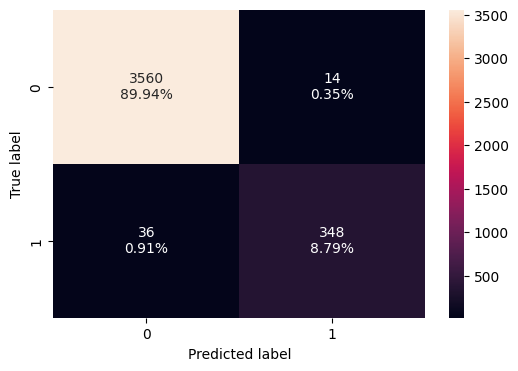

In [ ]:
plot_confusion_matrix(dtree2, X_train, y_train)

In [ ]:
dtree2_train_perf = model_performance_classification(
    dtree2, X_train, y_train
)
dtree2_train_perf

,Accuracy,Recall,Precision,F1
0,0.987367,0.90625,0.961326,0.932976


In [ ]:
dtree2_test_perf = model_performance_classification(
    dtree2, X_test, y_test
)
dtree2_test_perf

,Accuracy,Recall,Precision,F1
0,0.984848,0.895833,0.945055,0.919786


#### Visualizing the pre-pruned Decision Tree

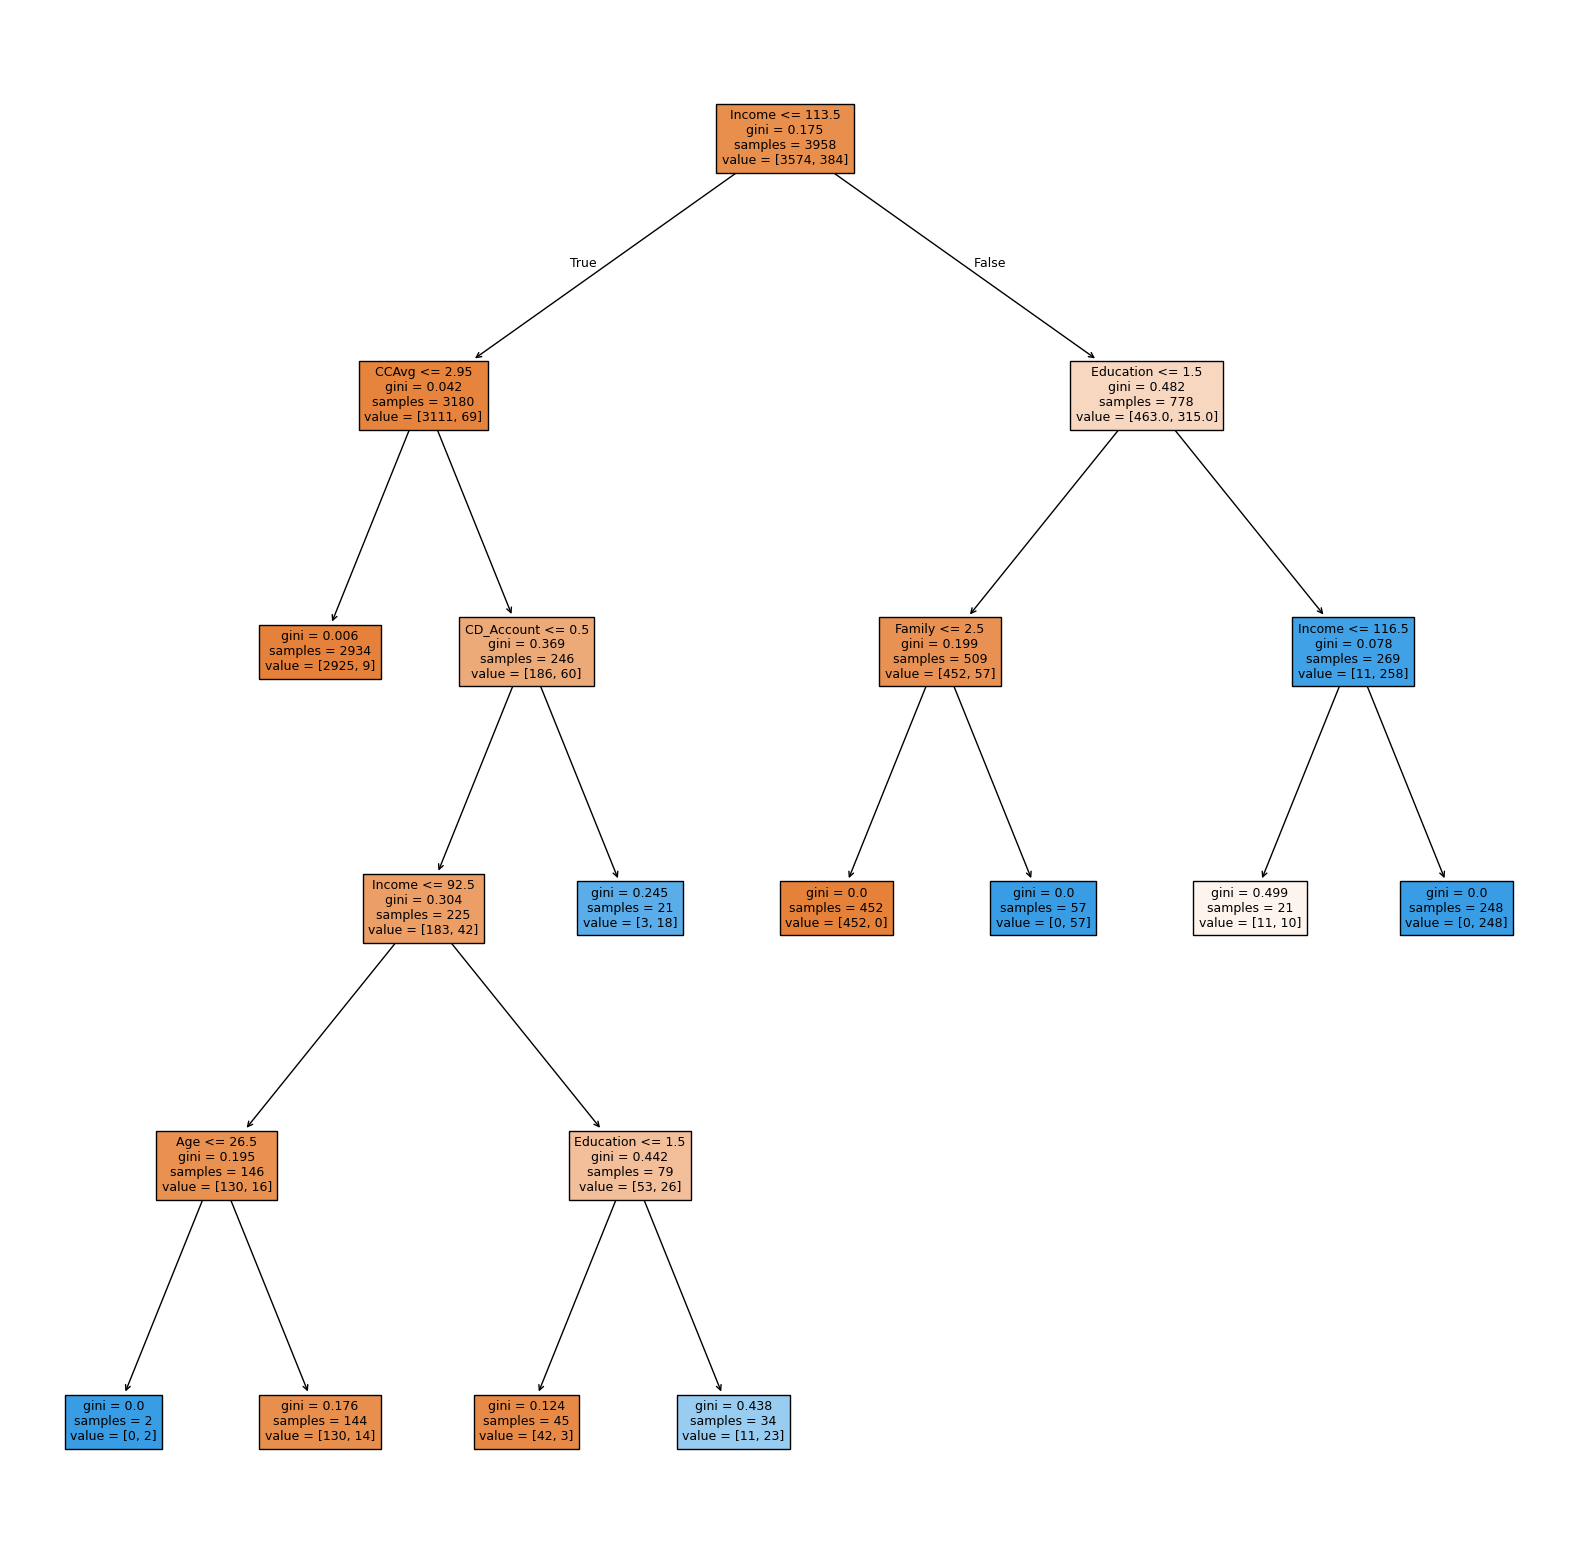

In [ ]:
# list of feature names in X_train
feature_names = list(X_train.columns)

# set the figure size for the plot
plt.figure(figsize=(20, 20))

# plotting the decision tree
out = tree.plot_tree(
    dtree2,                         # decision tree classifier model
    feature_names=feature_names,    # list of feature names (columns) in the dataset
    filled=True,                    # fill the nodes with colors based on class
    fontsize=9,                     # font size for the node text
    node_ids=False,                 # do not show the ID of each node
    class_names=None,               # whether or not to display class names
)

# add arrows to the decision tree splits if they are missing
for o in out:
    arrow = o.arrow_patch
    if arrow is not None:
        arrow.set_edgecolor("black")    # set arrow color to black
        arrow.set_linewidth(1)          # set arrow linewidth to 1

# displaying the plot
plt.show()

This is a far less complex tree than the previous one.
Next step is to perform post-pruning and select the best model

### Decision Tree (Post-pruning)
We build the full tree, find multiple smaller ones, choose the best one

In [ ]:
# Create an instance of the decision tree model
clf = DecisionTreeClassifier(random_state=42)

# Compute the cost complexity pruning path for the model using the training data
path = clf.cost_complexity_pruning_path(X_train, y_train)

# Extract the array of effective alphas from the pruning path
ccp_alphas = abs(path.ccp_alphas)

# Extract the array of total impurities at each alpha along the pruning path
impurities = path.impurities

Above code gives us a sequence of alpha values and their corresponding impurity values.

In [ ]:
pd.DataFrame({
    "alpha": ccp_alphas,
    "impurity": impurities
})

,alpha,impurity
0,0.000000,0.000000
1,0.000196,0.000982
2,0.000202,0.001386
3,0.000211,0.001807
4,0.000211,0.002229
5,0.000221,0.002671
6,0.000227,0.003125
7,0.000244,0.003613
8,0.000247,0.004106
9,0.000262,0.004629


The pruning path gives 32 different versions of the same tree . For each version, we get an alpha value and an impurity value.
Next step is to plot is the plot alpha and impurity value to understand how much accuracy (confidence) is lost in each step

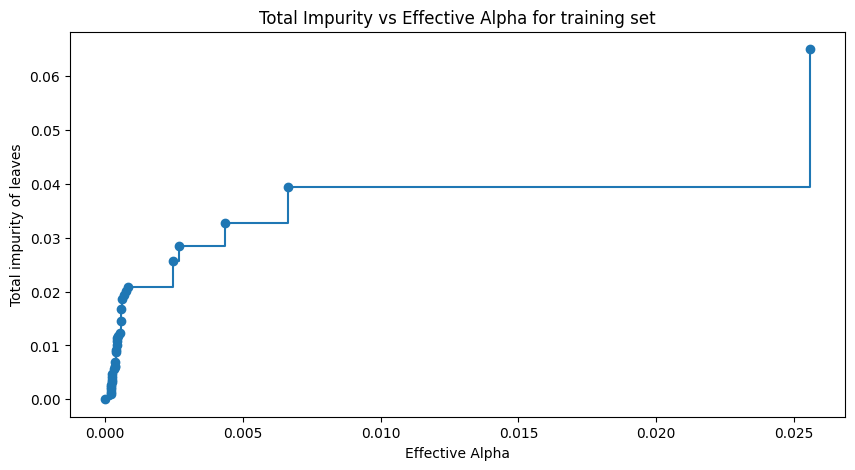

In [ ]:
# Create a figure
fig, ax = plt.subplots(figsize=(10, 5))

# Plot the total impurities versus effective alphas, excluding the last value,
# using markers at each data point and connecting them with steps
ax.plot(ccp_alphas[:-1], impurities[:-1], marker="o", drawstyle="steps-post")

# Set the x-axis label
ax.set_xlabel("Effective Alpha")

# Set the y-axis label
ax.set_ylabel("Total impurity of leaves")

# Set the title of the plot
ax.set_title("Total Impurity vs Effective Alpha for training set");

This is backwards. Reword to: "As alpha increases, impurity rises gradually up to about 0.04, then jumps sharply after alpha ≈ 0.025

Now We evaluate all alpha values by building models and checking F1, recall, and gap. Then we compare them and choose the model that gives the best balance.
Post-pruning reduces the overfiting however finding score gap between F1 train score and F1 test score is not a bad idea.

In [ ]:
results = []

for alpha in ccp_alphas[:-1]:   # skip last trivial tree
    model = DecisionTreeClassifier(ccp_alpha=alpha, random_state=42)
    model.fit(X_train, y_train)

    # predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # metrics
    train_f1 = f1_score(y_train, y_train_pred)
    test_f1 = f1_score(y_test, y_test_pred)
    test_recall = recall_score(y_test, y_test_pred)

    score_gap = abs(train_f1 - test_f1)


    results.append({
        "alpha": alpha,
        "train_f1": train_f1,
        "test_f1": test_f1,
        "test_recall": test_recall,
        "score_gap": score_gap
    })

# convert to dataframe
results_df = pd.DataFrame(results)

# sort by best test F1
results_best_test_f1 = results_df.sort_values(by="test_f1", ascending=False)

print("Best test F1 ")
print(results_best_test_f1.head(5))

# sort by best score gap

results_best_score = results_df.sort_values(by="score_gap", ascending=True)

print("\nbest score gap")
print(results_best_score.head(5))

# sort by best recall

results_best_recall = results_df.sort_values(by="test_recall", ascending=False)
print("\nbest recall")
print(results_best_recall.head(5))


Best test F1 
       alpha  train_f1   test_f1  test_recall  score_gap
1   0.000196  0.997389  0.927083     0.927083   0.070306
2   0.000202  0.996078  0.927083     0.927083   0.068995
7   0.000244  0.989556  0.927083     0.927083   0.062473
8   0.000247  0.988235  0.927083     0.927083   0.061152
23  0.000625  0.941489  0.926316     0.916667   0.015174

best score gap
       alpha  train_f1   test_f1  test_recall  score_gap
30  0.006652  0.887324  0.885246     0.843750   0.002078
29  0.004363  0.887324  0.885246     0.843750   0.002078
26  0.000812  0.930108  0.919786     0.895833   0.010321
25  0.000752  0.932976  0.919786     0.895833   0.013190
23  0.000625  0.941489  0.926316     0.916667   0.015174

best recall
      alpha  train_f1   test_f1  test_recall  score_gap
0  0.000000  1.000000  0.917526     0.927083   0.082474
1  0.000196  0.997389  0.927083     0.927083   0.070306
2  0.000202  0.996078  0.927083     0.927083   0.068995
3  0.000211  0.993481  0.922280     0.927083   0.

After examing the results, we can see alpha = 0.000196 gives the best model.
best score gap is eliminated as it has the significant lower F1 and recall scores.

**Note to instructor, I first selected the alpha as 0.000196 and ran through the performance metrics, while this has best F1 and recall metrics, the decision tree was still complex as 0.000196 barely purned the tree**

I selected alpha=0.000625: F1=0.885, gap=0.002 (well-pruned, generalizes well)

Assigning alpha=0.000625 for dtree3

In [ ]:
dtree3 = DecisionTreeClassifier(ccp_alpha=0.000625, random_state=42)
dtree3.fit(X_train, y_train)

DecisionTreeClassifier(ccp_alpha=0.000625, random_state=42)

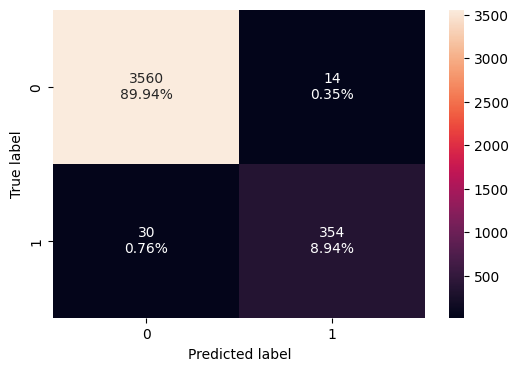

In [ ]:
plot_confusion_matrix(dtree3, X_train, y_train)

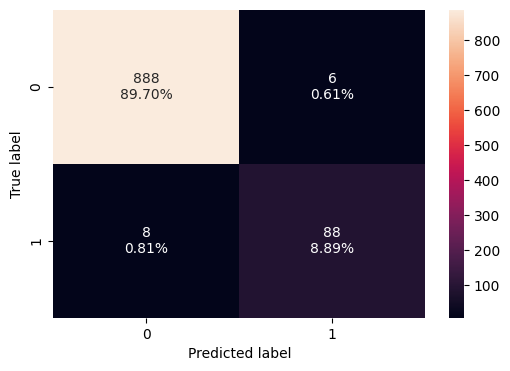

In [ ]:
plot_confusion_matrix(dtree3, X_test, y_test)

In [ ]:
dtree3_train_perf = model_performance_classification(
    dtree3, X_train, y_train
)
print(dtree3_train_perf)

dtree3_test_perf = model_performance_classification(
    dtree3, X_test, y_test
)
print("\n Test Performance" )
print(dtree3_test_perf)

   Accuracy    Recall  Precision        F1
0  0.988883  0.921875   0.961957  0.941489

 Test Performance
   Accuracy    Recall  Precision        F1
0  0.985859  0.916667    0.93617  0.926316


#### Visualizing Decision Tree

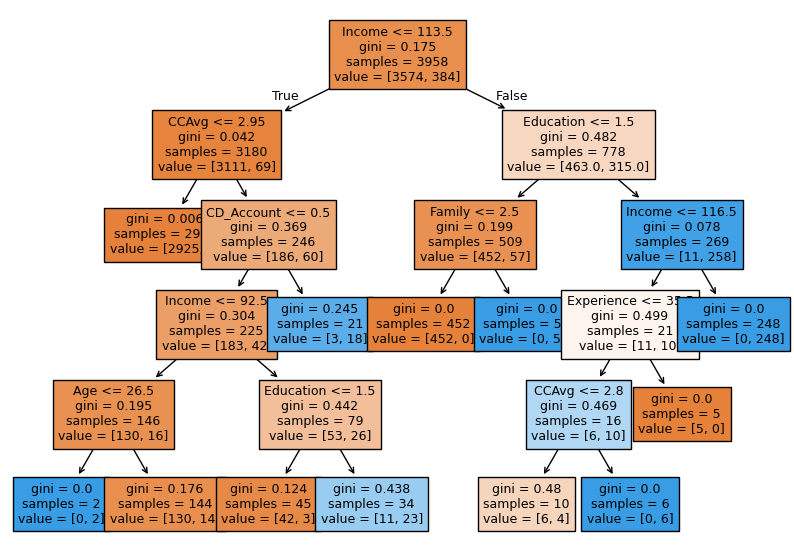

In [ ]:
# list of feature names in X_train
feature_names = list(X_train.columns)

# set the figure size for the plot
plt.figure(figsize=(10, 7))

# plotting the decision tree
out = tree.plot_tree(
    dtree3,                         # decision tree classifier model
    feature_names=feature_names,    # list of feature names (columns) in the dataset
    filled=True,                    # fill the nodes with colors based on class
    fontsize=9,                     # font size for the node text
    node_ids=False,                 # do not show the ID of each node
    class_names=None,               # whether or not to display class names
)

# add arrows to the decision tree splits if they are missing
for o in out:
    arrow = o.arrow_patch
    if arrow is not None:
        arrow.set_edgecolor("black")    # set arrow color to black
        arrow.set_linewidth(1)          # set arrow linewidth to 1

# displaying the plot
plt.show()

This decision tree is far simpler than the default unpruned tree while maintaining strong performance

## Model Performance Improvement

In [ ]:
# training performance comparison

models_train_comp_df = pd.concat(
    [
        dtree1_train_perf.T,
        dtree2_train_perf.T,
        dtree3_train_perf.T,
    ],
    axis=1,
)
models_train_comp_df.columns = [
    "Decision Tree (sklearn default)",
    "Decision Tree (Pre-Pruning)",
    "Decision Tree (Post-Pruning)",
]
print("Training performance comparison:")
models_train_comp_df

Training performance comparison:


,Decision Tree (sklearn default),Decision Tree (Pre-Pruning),Decision Tree (Post-Pruning)
Accuracy,1.0,0.987367,0.988883
Recall,1.0,0.906250,0.921875
Precision,1.0,0.961326,0.961957
F1,1.0,0.932976,0.941489


In [ ]:
# testing performance comparison

models_test_comp_df = pd.concat(
    [
        dtree1_test_perf.T,
        dtree2_test_perf.T,
        dtree3_test_perf.T,
    ],
    axis=1,
)
models_test_comp_df.columns = [
    "Decision Tree (sklearn default)",
    "Decision Tree (Pre-Pruning)",
    "Decision Tree (Post-Pruning)",
]
print("Test set performance comparison:")
models_test_comp_df

Test set performance comparison:


,Decision Tree (sklearn default),Decision Tree (Pre-Pruning),Decision Tree (Post-Pruning)
Accuracy,0.983838,0.984848,0.985859
Recall,0.927083,0.895833,0.916667
Precision,0.908163,0.945055,0.936170
F1,0.917526,0.919786,0.926316


Among the three models, the **Post-Pruned Decision** Tree is selected as the final model.

The Pre-Pruned model shows slightly higher precision and comparable F1 score with  Post-Pruned, the Post-Pruned model achieves a higher recall.

Since the business objective is to identify  potential customers  who are likely to accept the personal loan, recall becomes the most important metric.
Hence Post-Pruned model is selected.

Since the post-pruned model is selected, we will print the rules of the decision tree to understand the decision logic.

In [ ]:
# printing a text report showing the rules of a decision tree
print(
    tree.export_text(
        dtree3,    # specify the model
        feature_names=feature_names,    # specify the feature names
        show_weights=True    # specify whether or not to show the weights associated with the model
    )
)

|--- Income <= 113.50
|   |--- CCAvg <= 2.95
|   |   |--- weights: [2925.00, 9.00] class: 0
|   |--- CCAvg >  2.95
|   |   |--- CD_Account <= 0.50
|   |   |   |--- Income <= 92.50
|   |   |   |   |--- Age <= 26.50
|   |   |   |   |   |--- weights: [0.00, 2.00] class: 1
|   |   |   |   |--- Age >  26.50
|   |   |   |   |   |--- weights: [130.00, 14.00] class: 0
|   |   |   |--- Income >  92.50
|   |   |   |   |--- Education <= 1.50
|   |   |   |   |   |--- weights: [42.00, 3.00] class: 0
|   |   |   |   |--- Education >  1.50
|   |   |   |   |   |--- weights: [11.00, 23.00] class: 1
|   |   |--- CD_Account >  0.50
|   |   |   |--- weights: [3.00, 18.00] class: 1
|--- Income >  113.50
|   |--- Education <= 1.50
|   |   |--- Family <= 2.50
|   |   |   |--- weights: [452.00, 0.00] class: 0
|   |   |--- Family >  2.50
|   |   |   |--- weights: [0.00, 57.00] class: 1
|   |--- Education >  1.50
|   |   |--- Income <= 116.50
|   |   |   |--- Experience <= 35.50
|   |   |   |   |--- CCAvg <= 2.

Rules of the decision tress helps business to understand the primary drivers.

Income ≤ 113.5
samples = 3180
value = [3111, 69]
3111 → No loan
69 → Yes loan
Income >Income > 113.5
samples = 778
value = [463, 315]
463 → No
315 → Yes
High Income tend to take loans or accpet loans.
CCAvg <= 2.95
[2925.00, 9.00]
Only 9 ppl took loans.
CUstomers > 160k income with Graduate, Advanced/Professional are more likely to accept loans.
Income <= 113.5
CCAvg <= 2.95
[2925.00, 9.00]
Low income and low credit card spenders are low likely to accept loans



## Actionable Insights and Business Recommendations


* What recommedations would you suggest to the bank?

The bank can use this model to identify customers who are most likely to accept personal loan offers. Instead of using a binary decision, the model can generate a probability score, allowing the bank to prioritize high-probability customers for targeted marketing campaigns.

Customers with higher income, higher credit card spending, and CD accounts should be prioritized, as they are more likely to accept loans. These segments can be targeted through personalized offers and proactive outreach.

Customers with low income and low credit card spending can be deprioritized.

Customers with moderate probability can be routed for manual review


___